# 🗄️ PostgreSQL Decision Logger
### Persistent Storage for LLM Agent Simulation Runs

This notebook implements the **database logging layer** for the supply chain digital twin.
Every agent decision and daily state is persisted so experiments can be analysed across sessions.


In [1]:
!pip install psycopg2-binary sqlalchemy mesa pandas matplotlib --break-system-packages -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.1/275.1 kB 6.0 MB/s eta 0:00:00


In [2]:
import os, json, random, warnings
from collections import deque
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlalchemy as sa
from sqlalchemy import text
from mesa import Agent, Model
from mesa.datacollection import DataCollector
warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)
print('✅ Imports OK')


✅ Imports OK


In [3]:
# ── Database configuration
# USE_SQLITE=True  → runs without a server (SQLite file, perfect for Colab/testing)
# USE_SQLITE=False → connect to real PostgreSQL (VU MIF server or Supabase)

USE_SQLITE  = True
PG_HOST     = 'localhost'
PG_PORT     = 5432
PG_DATABASE = 'supply_chain'
PG_USER     = 'postgres'
PG_PASSWORD = os.environ.get('PG_PASSWORD', 'your_password_here')

DB_URL = ('sqlite:///outputs/supply_chain_sim.db' if USE_SQLITE
          else f'postgresql+psycopg2://{PG_USER}:{PG_PASSWORD}@{PG_HOST}:{PG_PORT}/{PG_DATABASE}')

engine = sa.create_engine(DB_URL, echo=False)
with engine.connect() as conn:
    conn.execute(text('SELECT 1'))
print(f'✅ Connected: {"SQLite" if USE_SQLITE else "PostgreSQL"}')


✅ Connected: SQLite


In [4]:
# ── Create tables (idempotent)

DDL_SQLITE = '''
CREATE TABLE IF NOT EXISTS simulation_runs (
    run_id     INTEGER PRIMARY KEY AUTOINCREMENT,
    scenario   TEXT NOT NULL,
    agent_type TEXT NOT NULL,
    objective  TEXT,
    lead_time  INTEGER NOT NULL,
    seed       INTEGER NOT NULL,
    steps      INTEGER NOT NULL,
    created_at TEXT DEFAULT (datetime('now'))
);
CREATE TABLE IF NOT EXISTS daily_states (
    id               INTEGER PRIMARY KEY AUTOINCREMENT,
    run_id           INTEGER NOT NULL REFERENCES simulation_runs(run_id),
    day              INTEGER NOT NULL,
    inventory        INTEGER,
    backlog          INTEGER,
    demand           INTEGER,
    order_qty        INTEGER,
    holding_cost_cum REAL,
    backlog_cost_cum REAL,
    reasoning        TEXT
);
CREATE TABLE IF NOT EXISTS run_kpis (
    run_id            INTEGER PRIMARY KEY REFERENCES simulation_runs(run_id),
    service_level_pct REAL,
    fill_rate_pct     REAL,
    avg_inventory     REAL,
    avg_backlog       REAL,
    total_cost        REAL,
    order_freq_pct    REAL,
    bullwhip_ratio    REAL
);
'''

DDL_PG = (DDL_SQLITE
    .replace('INTEGER PRIMARY KEY AUTOINCREMENT', 'SERIAL PRIMARY KEY')
    .replace("DEFAULT (datetime('now'))", 'DEFAULT NOW()')
    .replace('REFERENCES simulation_runs(run_id)',
             'REFERENCES simulation_runs(run_id) ON DELETE CASCADE'))

DDL = DDL_SQLITE if USE_SQLITE else DDL_PG
with engine.begin() as conn:
    for stmt in DDL.strip().split(';'):
        s = stmt.strip()
        if s:
            conn.execute(text(s))
print('✅ Schema ready (3 tables)')


✅ Schema ready (3 tables)


In [5]:
# ── DB helper functions

def insert_run(conn, scenario, agent_type, objective, lead_time, seed, steps):
    if USE_SQLITE:
        r = conn.execute(text(
            'INSERT INTO simulation_runs (scenario,agent_type,objective,lead_time,seed,steps) '
            'VALUES (:scenario,:agent_type,:objective,:lead_time,:seed,:steps)'),
            dict(scenario=scenario, agent_type=agent_type, objective=objective or '',
                 lead_time=lead_time, seed=seed, steps=steps))
        return r.lastrowid
    else:
        r = conn.execute(text(
            'INSERT INTO simulation_runs (scenario,agent_type,objective,lead_time,seed,steps) '
            'VALUES (:scenario,:agent_type,:objective,:lead_time,:seed,:steps) RETURNING run_id'),
            dict(scenario=scenario, agent_type=agent_type, objective=objective or '',
                 lead_time=lead_time, seed=seed, steps=steps))
        return r.scalar()

def insert_daily_states(conn, run_id, df, log):
    rows = []
    for day, row in df.iterrows():
        reason = log[day]['reasoning'] if log and day < len(log) else ''
        rows.append(dict(run_id=run_id, day=int(day),
            inventory=int(row['Inventory']), backlog=int(row['Backlog']),
            demand=int(row['Demand']), order_qty=int(row['OrderQty']),
            holding_cost_cum=float(row['HoldingCost']),
            backlog_cost_cum=float(row['BacklogCost']), reasoning=reason))
    conn.execute(text(
        'INSERT INTO daily_states '
        '(run_id,day,inventory,backlog,demand,order_qty,holding_cost_cum,backlog_cost_cum,reasoning) '
        'VALUES (:run_id,:day,:inventory,:backlog,:demand,:order_qty,:holding_cost_cum,:backlog_cost_cum,:reasoning)'),
        rows)

def insert_kpis(conn, run_id, k):
    conn.execute(text(
        'INSERT INTO run_kpis '
        '(run_id,service_level_pct,fill_rate_pct,avg_inventory,avg_backlog,total_cost,order_freq_pct,bullwhip_ratio) '
        'VALUES (:run_id,:sl,:fr,:ai,:ab,:tc,:of,:bwr)'),
        dict(run_id=run_id, sl=k['Service Level %'], fr=k['Fill Rate %'],
             ai=k['Avg Inventory'], ab=k['Avg Backlog'], tc=k['Total Cost ($)'],
             of=k['Order Freq %'], bwr=k['Bullwhip Ratio']))

print('✅ DB helpers defined')


✅ DB helpers defined


In [6]:
# ── Agents + model (self-contained)

class CustomerAgent(Agent):
    def __init__(self, model, mean=20, std=5, shock_day=None, shock_mult=3.0):
        super().__init__(model)
        self.mean=mean; self.std=std; self.shock_day=shock_day
        self.shock_mult=shock_mult; self.daily_demand=0
    def step(self):
        d=max(0,random.gauss(self.mean,self.std))
        if self.shock_day and self.model.steps>=self.shock_day:
            days=self.model.steps-self.shock_day
            if days<14: d*=self.shock_mult*(1-days/28)
        self.daily_demand=int(d)

class SupplierAgent(Agent):
    def __init__(self, model, capacity=600, disruption_day=None, disruption_cap=150):
        super().__init__(model)
        self.base_capacity=capacity; self.disruption_day=disruption_day
        self.disruption_cap=disruption_cap; self.pending_orders=[]
    @property
    def capacity(self):
        if self.disruption_day and self.model.steps>=self.disruption_day:
            return self.disruption_cap
        return self.base_capacity
    def receive_order(self,r,qty,lt):
        self.pending_orders.append((r,qty,self.model.steps+lt))
    def step(self):
        remaining,still=self.capacity,[]
        for (r,qty,due) in self.pending_orders:
            if due<=self.model.steps and remaining>0:
                s=min(qty,remaining); r.receive_shipment(s); remaining-=s
                if s<qty: still.append((r,qty-s,due+1))
            else: still.append((r,qty,due))
        self.pending_orders=still

class LLMHeuristicRetailer(Agent):
    def __init__(self, model, supplier, lead_time=3, objective='cost', **kw):
        super().__init__(model)
        self.supplier=supplier; self.inventory=400; self.lead_time=lead_time
        self.objective=objective; self.backlog=0
        self.total_holding_cost=0.0; self.total_backlog_cost=0.0
        self.order_qty_today=0; self._window=deque(maxlen=7); self.decision_log=[]
    def receive_shipment(self,qty):
        self.inventory+=qty; self.backlog-=min(self.backlog,qty)
    def step(self):
        demand=sum(c.daily_demand for c in self.model.agents if isinstance(c,CustomerAgent))
        fulfilled=min(demand,self.inventory)
        self.inventory-=fulfilled; self.backlog+=demand-fulfilled
        self.total_holding_cost+=self.inventory; self.total_backlog_cost+=self.backlog*5
        self.order_qty_today=0
        self._window.append(demand)
        avg_d=np.mean(self._window); std_d=np.std(self._window) if len(self._window)>1 else 5
        z={'cost':1.28,'availability':2.05,'covid':1.65}.get(self.objective,1.28)
        target=avg_d*self.lead_time+z*std_d*np.sqrt(self.lead_time)
        urgency=1.0+min(self.backlog/50,0.5)
        qty=0
        if self.inventory<target:
            qty=int((target-self.inventory)*urgency)
            if self.objective=='covid': qty=int(min(qty,self.supplier.capacity*0.4))
        if qty>0:
            self.supplier.receive_order(self,qty,self.lead_time)
            self.order_qty_today=qty
        self.decision_log.append({'day':self.model.steps,'inventory':self.inventory,
            'backlog':self.backlog,'demand':demand,'order_qty':qty,
            'reasoning':f'[{self.objective}] inv={self.inventory} target={target:.0f} order={qty}'})

class ScenarioModel(Model):
    def __init__(self, objective='cost', lead_time=3, supplier_cap=600,
                 shock_day=None, shock_mult=3.0, disruption_day=None,
                 disruption_cap=150, seed=42):
        super().__init__(rng=seed); random.seed(seed)
        self.supplier=SupplierAgent(self,capacity=supplier_cap,
            disruption_day=disruption_day,disruption_cap=disruption_cap)
        self.retailer=LLMHeuristicRetailer(self,self.supplier,
            lead_time=lead_time,objective=objective)
        for _ in range(5):
            CustomerAgent(self,shock_day=shock_day,shock_mult=shock_mult)
        self.datacollector=DataCollector(model_reporters={
            'Inventory':lambda m:m.retailer.inventory,
            'Backlog':lambda m:m.retailer.backlog,
            'HoldingCost':lambda m:m.retailer.total_holding_cost,
            'BacklogCost':lambda m:m.retailer.total_backlog_cost,
            'Demand':lambda m:sum(c.daily_demand for c in m.agents if isinstance(c,CustomerAgent)),
            'OrderQty':lambda m:m.retailer.order_qty_today,
        })
    def step(self):
        for a in self.agents:
            if isinstance(a,CustomerAgent): a.step()
        for a in self.agents:
            if isinstance(a,SupplierAgent): a.step()
        for a in self.agents:
            if isinstance(a,LLMHeuristicRetailer): a.step()
        self.datacollector.collect(self)
    def run(self,steps=90):
        for _ in range(steps): self.step()
        return self.datacollector.get_model_vars_dataframe()

def compute_kpis(df,label):
    ds=df['Demand'].std(); os_=df['OrderQty'].std()
    bwr=(os_/ds) if ds>0 else float('nan')
    td=df['Demand'].sum(); uf=df['Backlog'].diff().clip(lower=0).fillna(0).sum()
    fr=1-(uf/td) if td>0 else 1.0
    return {'Scenario':label,'Service Level %':round(100*(1-(df['Backlog']>0).mean()),1),
            'Fill Rate %':round(100*fr,1),'Avg Inventory':round(df['Inventory'].mean(),1),
            'Avg Backlog':round(df['Backlog'].mean(),1),
            'Total Cost ($)':round(df['HoldingCost'].iloc[-1]+df['BacklogCost'].iloc[-1],0),
            'Order Freq %':round(100*(df['OrderQty']>0).mean(),1),
            'Bullwhip Ratio':round(bwr,3)}

print('✅ Agents + model defined')


✅ Agents + model defined


In [7]:
# ── Run scenarios and log everything to DB

STEPS = 90
run_configs = [
    ('Normal - Cost Focus',       dict(objective='cost',         lead_time=3, supplier_cap=600, seed=42)),
    ('Normal - Availability',     dict(objective='availability', lead_time=3, supplier_cap=600, seed=42)),
    ('Disruption - Long LT',      dict(objective='availability', lead_time=7, supplier_cap=600, seed=42)),
    ('COVID - Shock+Disruption',  dict(objective='covid',        lead_time=7, supplier_cap=600, seed=42,
                                       shock_day=30, shock_mult=2.5,
                                       disruption_day=35, disruption_cap=150)),
]

logged_ids = []
for scenario, cfg in run_configs:
    m  = ScenarioModel(**cfg)
    df = m.run(steps=STEPS)
    k  = compute_kpis(df, scenario)
    with engine.begin() as conn:
        rid = insert_run(conn, scenario=scenario, agent_type='LLMHeuristicRetailer',
                         objective=cfg.get('objective',''), lead_time=cfg.get('lead_time',3),
                         seed=cfg.get('seed',42), steps=STEPS)
        insert_daily_states(conn, rid, df, m.retailer.decision_log)
        insert_kpis(conn, rid, k)
    logged_ids.append(rid)
    print(f'  [run_id={rid}] {scenario:<30} SL={k["Service Level %"]}%  TC={k["Total Cost ($)"]:.0f}')

print(f'\n✅ {len(run_configs)} runs logged. IDs: {logged_ids}')


  [run_id=1] Normal - Cost Focus            SL=98.9%  TC=25089
  [run_id=2] Normal - Availability          SL=100.0%  TC=26166
  [run_id=3] Disruption - Long LT           SL=96.7%  TC=197727
  [run_id=4] COVID - Shock+Disruption       SL=44.4%  TC=42081

✅ 4 runs logged. IDs: [1, 2, 3, 4]


In [8]:
# ── SQL Query 1: KPI leaderboard

with engine.connect() as conn:
    df_kpi = pd.read_sql(text("""
        SELECT r.run_id, r.scenario, r.objective, r.lead_time,
               k.service_level_pct, k.fill_rate_pct, k.avg_inventory,
               k.total_cost, k.bullwhip_ratio
        FROM simulation_runs r JOIN run_kpis k ON r.run_id=k.run_id
        ORDER BY k.total_cost ASC
    """), conn)
print('KPI Leaderboard (sorted by Total Cost):')
print(df_kpi.to_string(index=False))


KPI Leaderboard (sorted by Total Cost):
 run_id                 scenario    objective  lead_time  service_level_pct  fill_rate_pct  avg_inventory  total_cost  bullwhip_ratio
      1      Normal - Cost Focus         cost          3               98.9          100.0          278.6     25089.0          10.189
      2    Normal - Availability availability          3              100.0          100.0          290.7     26166.0          10.098
      4 COVID - Shock+Disruption        covid          7               44.4           90.0          236.0     42081.0           1.872
      3     Disruption - Long LT availability          7               96.7           97.1         2167.1    197727.0          23.148


In [9]:
# ── SQL Query 2: Worst stockout days across all runs

with engine.connect() as conn:
    df_so = pd.read_sql(text("""
        SELECT r.scenario, d.day, d.backlog, d.demand, d.inventory, d.reasoning
        FROM daily_states d JOIN simulation_runs r ON d.run_id=r.run_id
        WHERE d.backlog > 0
        ORDER BY d.backlog DESC LIMIT 10
    """), conn)
print('Top 10 worst stockout days:')
print(df_so.to_string(index=False))


Top 10 worst stockout days:
                scenario  day  backlog  demand  inventory                                  reasoning
COVID - Shock+Disruption   32      521     271          0        [covid] inv=0 target=1654 order=240
COVID - Shock+Disruption   33      462     233          0        [covid] inv=0 target=1749 order=240
COVID - Shock+Disruption   31      368     250          0        [covid] inv=0 target=1476 order=240
COVID - Shock+Disruption   34      360     198          0         [covid] inv=0 target=1782 order=60
    Disruption - Long LT    6      259      71          0 [availability] inv=0 target=716 order=1073
COVID - Shock+Disruption    6      259      71          0         [covid] inv=0 target=705 order=240
COVID - Shock+Disruption   35      258     198          0         [covid] inv=0 target=1757 order=60
    Disruption - Long LT    5      188      97          0 [availability] inv=0 target=712 order=1067
COVID - Shock+Disruption    5      188      97          0      

In [10]:
# ── SQL Query 3: Ordering behaviour — avg/max order size per scenario
#    Used to detect Bullwhip panic-buying patterns

with engine.connect() as conn:
    df_ord = pd.read_sql(text("""
        SELECT r.scenario,
               COUNT(CASE WHEN d.order_qty>0 THEN 1 END)          AS days_ordered,
               ROUND(AVG(CASE WHEN d.order_qty>0 THEN d.order_qty END),1) AS avg_order,
               MAX(d.order_qty)                                   AS max_order,
               ROUND(AVG(d.inventory),1)                          AS avg_inventory
        FROM daily_states d JOIN simulation_runs r ON d.run_id=r.run_id
        GROUP BY r.run_id, r.scenario
        ORDER BY avg_order DESC
    """), conn)
print('Ordering behaviour by scenario:')
print(df_ord.to_string(index=False))


Ordering behaviour by scenario:
                scenario  days_ordered  avg_order  max_order  avg_inventory
    Disruption - Long LT            20      518.2       1073         2167.1
     Normal - Cost Focus            51      181.4        324          278.6
   Normal - Availability            52      178.9        304          290.7
COVID - Shock+Disruption            77      101.9        240          236.0


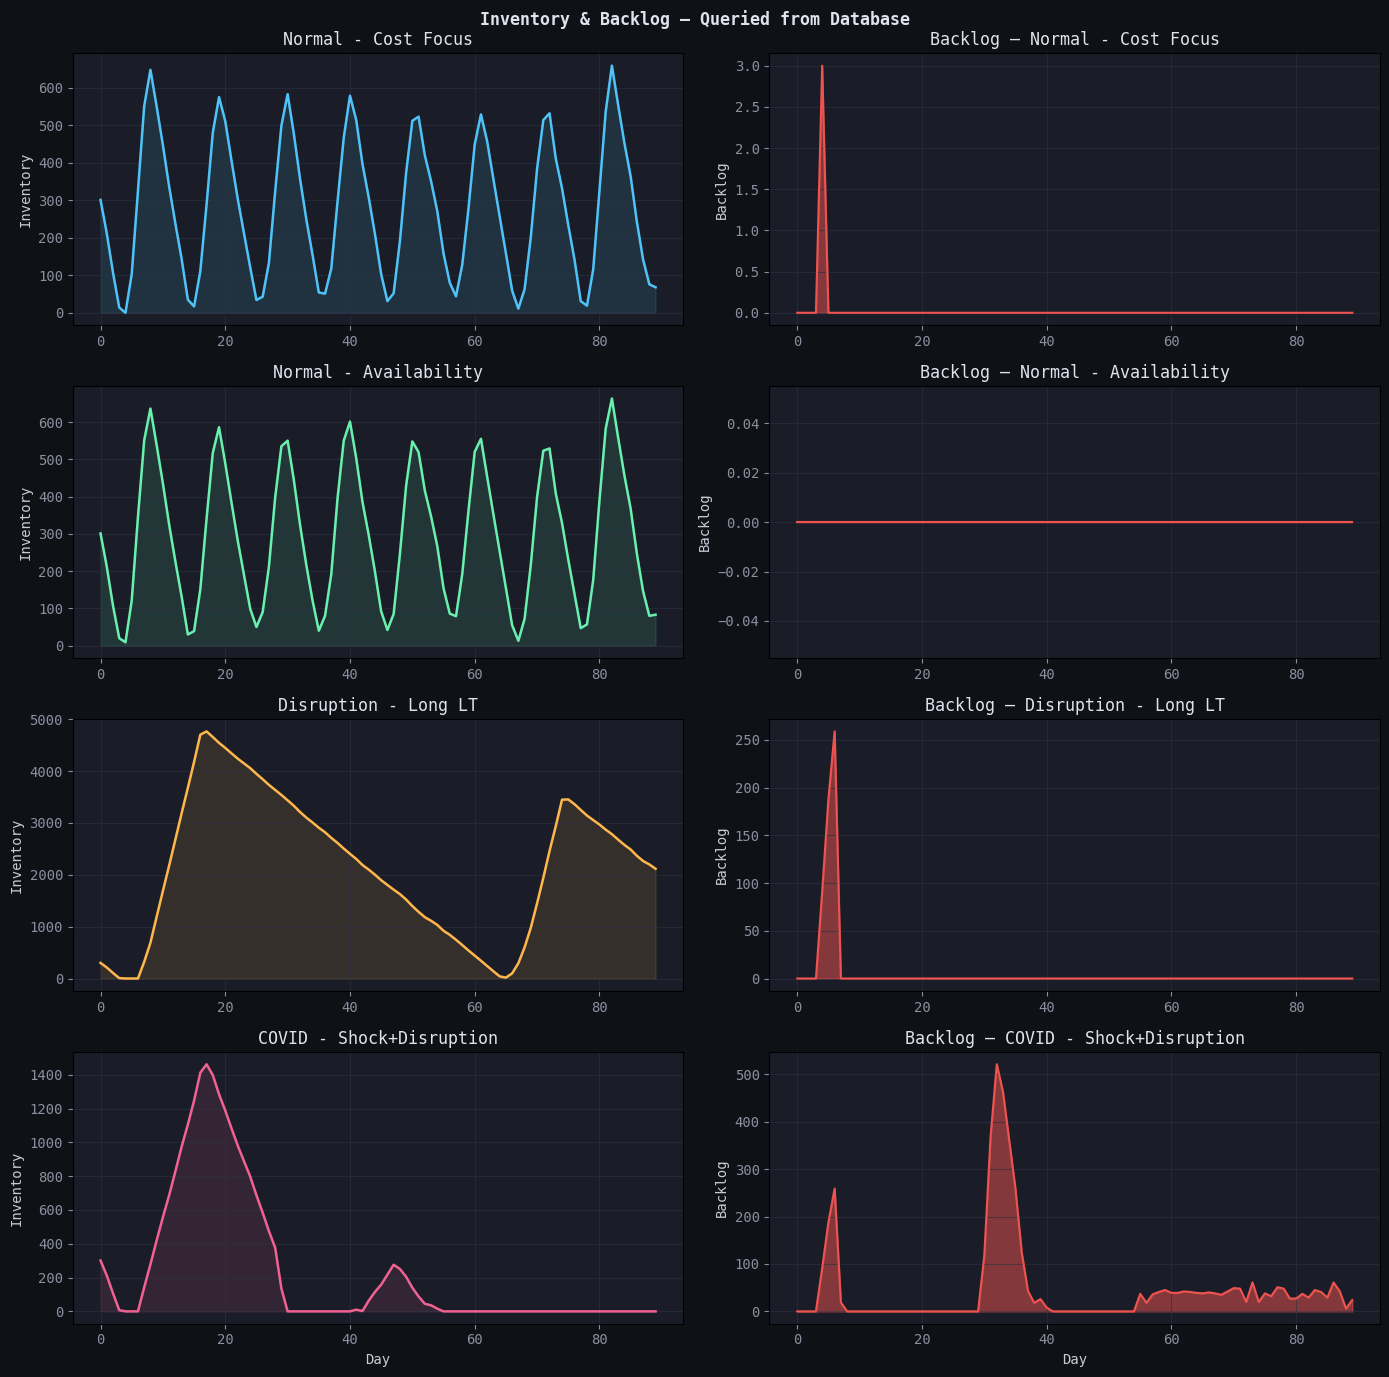

📊 outputs/db_trajectories.png


In [11]:
# ── Visualise trajectories pulled directly from DB

plt.rcParams.update({'figure.facecolor':'#0f1117','axes.facecolor':'#1a1d27',
    'text.color':'#e0e3ed','axes.labelcolor':'#c8ccd8',
    'xtick.color':'#8b90a0','ytick.color':'#8b90a0',
    'grid.color':'#2d3142','grid.alpha':0.6,'font.family':'monospace'})

COLORS=['#4fc3f7','#69f0ae','#ffb74d','#f06292']
with engine.connect() as conn:
    df_all=pd.read_sql(text("""
        SELECT r.scenario,d.day,d.inventory,d.backlog
        FROM daily_states d JOIN simulation_runs r ON d.run_id=r.run_id
        ORDER BY r.run_id,d.day
    """), conn)

scenarios=df_all['scenario'].unique()
fig,axes=plt.subplots(len(scenarios),2,figsize=(14,3.5*len(scenarios)))
if len(scenarios)==1: axes=axes[np.newaxis,:]
fig.suptitle('Inventory & Backlog — Queried from Database',fontsize=12,fontweight='bold')
for i,(sc,col) in enumerate(zip(scenarios,COLORS)):
    sub=df_all[df_all['scenario']==sc].sort_values('day')
    ax=axes[i][0]
    ax.plot(sub['day'],sub['inventory'],color=col,lw=1.8)
    ax.fill_between(sub['day'],0,sub['inventory'],alpha=0.12,color=col)
    ax.set_title(sc); ax.set_ylabel('Inventory'); ax.grid(True)
    ax2=axes[i][1]
    ax2.fill_between(sub['day'],sub['backlog'],color='#ef5350',alpha=0.5)
    ax2.plot(sub['day'],sub['backlog'],color='#ef5350',lw=1.5)
    ax2.set_title(f'Backlog — {sc}'); ax2.set_ylabel('Backlog'); ax2.grid(True)
for ax in axes[-1]: ax.set_xlabel('Day')
plt.tight_layout()
plt.savefig('outputs/db_trajectories.png',dpi=150,bbox_inches='tight',facecolor='#0f1117')
plt.show()
print('📊 outputs/db_trajectories.png')


In [12]:
# ── Export full dataset to CSV for paper/analysis

with engine.connect() as conn:
    df_ex=pd.read_sql(text("""
        SELECT r.run_id,r.scenario,r.objective,r.lead_time,r.seed,
               d.day,d.inventory,d.backlog,d.demand,d.order_qty,
               d.holding_cost_cum,d.backlog_cost_cum,d.reasoning
        FROM daily_states d JOIN simulation_runs r ON d.run_id=r.run_id
        ORDER BY r.run_id,d.day
    """), conn)
df_ex.to_csv('outputs/full_simulation_data.csv',index=False)
print(f'📄 Exported {len(df_ex)} rows — outputs/full_simulation_data.csv')
print(f'   Runs: {df_ex["run_id"].nunique()}  |  Days per run: 90')


📄 Exported 360 rows — outputs/full_simulation_data.csv
   Runs: 4  |  Days per run: 90


## Switching to Real PostgreSQL (VU MIF Server)

1. Set `USE_SQLITE = False`
2. Fill in `PG_HOST`, `PG_DATABASE`, `PG_USER`
3. Set password via env var (never hardcode):
   ```python
   import os; os.environ['PG_PASSWORD'] = 'your_password'
   ```
4. Re-run the schema cell — DDL auto-adjusts for PostgreSQL syntax.

The same Python code works for both databases — only the `DB_URL` string changes.
SQLAlchemy handles all dialect differences transparently.

**Free cloud option (works from Colab):** [supabase.com](https://supabase.com) → New project → Settings → Database → copy connection string.
